In [35]:
import numpy as np
import random

In [36]:
# 환경 (Environment)
class KoreaJeonseFraudEnv:
    def __init__(self):
        """
        상태(state):
        0: 대항력 발생 시점 (0: 즉시, 1: 익일)
        1: 전세가율 (70~100)
        2: 시세 투명성 (0: 낮음, 1: 높음)
        3: 집주인 세금 체납 (0: 없음, 1: 있음)
        4: 보증보험 가입 가능 (0: 불가, 1: 가능)
        """

        # 규제 파라미터 (정책 변수)
        self.regulation = {
            "instant_opposability": 0,   # 1이면 즉시 대항력
            "price_transparency": 0,     # 1이면 시세 공개
            "tax_info_share": 0,         # 1이면 체납 정보 공유
            "insurance_mandatory": 0     # 1이면 보증보험 의무
        }

        self.action_space = [0, 1, 2]
        """
        0: 깡통전세 (고전세가율)
        1: 대항력 공백 근저당
        2: 신축 빌라 업계약
        """

    def reset(self):
        self.state = np.array([
            0 if self.regulation["instant_opposability"] else np.random.choice([0,1]),
            np.random.randint(75, 101),   # 현실 전세가율 분포
            1 if self.regulation["price_transparency"] else np.random.choice([0,1]),
            np.random.choice([0,1]),
            1 if self.regulation["insurance_mandatory"] else np.random.choice([0,1])
        ])
        return tuple(self.state)

    def step(self, action):
        reward = 0
        done = True

        oppo, ratio, price_open, tax, insurance = self.state

        # 1️⃣ 대항력 공백 근저당
        if action == 1:
            if oppo == 1:
                reward = 100
                if tax and self.regulation["tax_info_share"]:
                    reward -= 60
                if insurance:
                    reward -= 40
            else:
                reward = -50

        # 2️⃣ 깡통전세
        elif action == 0:
            if ratio >= 90:
                reward = 80
                if insurance:
                    reward -= 50
                if tax and self.regulation["tax_info_share"]:
                    reward -= 30
            else:
                reward = 10

        # 3️⃣ 신축 빌라 업계약
        elif action == 2:
            if price_open == 0:
                reward = 70
                if insurance:
                    reward -= 40
            else:
                reward = -30

        return tuple(self.state), reward, done

In [37]:
# Q-Learning 에이전트
class QLearningAgent:
    def __init__(self, actions):
        self.q_table = {}
        self.actions = actions
        self.lr = 0.1
        self.gamma = 0.9
        self.epsilon = 0.4

    def get_action(self, state):
        if state not in self.q_table:
            self.q_table[state] = np.zeros(len(self.actions))

        if random.random() < self.epsilon:
            return random.choice(self.actions)
        return self.actions[np.argmax(self.q_table[state])]

    def learn(self, state, action, reward, next_state, done):
        if state not in self.q_table:
            self.q_table[state] = np.zeros(len(self.actions))
        if next_state not in self.q_table:
            self.q_table[next_state] = np.zeros(len(self.actions))

        target = reward if done else reward + self.gamma * np.max(self.q_table[next_state])
        self.q_table[state][action] += self.lr * (target - self.q_table[state][action])

    def decay_epsilon(self, min_epsilon=0.05, decay=0.995):
        self.epsilon = max(min_epsilon, self.epsilon * decay)

In [38]:
# 실행부
env = KoreaJeonseFraudEnv()
agent = QLearningAgent(env.action_space)

EPISODES = 5000
rewards = []

for ep in range(EPISODES):
    state = env.reset()
    action = agent.get_action(state)
    next_state, reward, done = env.step(action)

    agent.learn(state, action, reward, next_state, done)
    agent.decay_epsilon()

    rewards.append(reward)

    if (ep+1) % 500 == 0:
        print(f"{ep+1}회 평균 보상: {np.mean(rewards[-500:]):.2f}")

500회 평균 보상: 26.76
1000회 평균 보상: 27.00
1500회 평균 보상: 30.36
2000회 평균 보상: 33.44
2500회 평균 보상: 31.12
3000회 평균 보상: 30.00
3500회 평균 보상: 32.26
4000회 평균 보상: 32.46
4500회 평균 보상: 31.22
5000회 평균 보상: 33.92


In [39]:
# 정책 효과 분석 예시
print("\n=== 대표 상태별 최적 사기 수법 ===")
for s, q in list(agent.q_table.items())[:10]:
    print(s, "→", np.argmax(q), q)


=== 대표 상태별 최적 사기 수법 ===
(np.int64(0), np.int64(92), np.int64(1), np.int64(0), np.int64(1)) → 0 [21.52711391  0.          0.        ]
(np.int64(1), np.int64(81), np.int64(1), np.int64(0), np.int64(0)) → 0 [7.71232075 0.         0.        ]
(np.int64(0), np.int64(97), np.int64(1), np.int64(1), np.int64(0)) → 0 [52.10572479  0.          0.        ]
(np.int64(0), np.int64(81), np.int64(1), np.int64(1), np.int64(1)) → 0 [8.14697981 0.         0.        ]
(np.int64(0), np.int64(95), np.int64(1), np.int64(1), np.int64(1)) → 0 [21.52711391 -5.         -3.        ]
(np.int64(0), np.int64(96), np.int64(0), np.int64(0), np.int64(1)) → 0 [24.44093943  0.          0.        ]
(np.int64(0), np.int64(90), np.int64(0), np.int64(0), np.int64(0)) → 0 [41.736248 -5.        0.      ]
(np.int64(1), np.int64(84), np.int64(1), np.int64(1), np.int64(0)) → 0 [7.71232075 0.         0.        ]
(np.int64(0), np.int64(78), np.int64(1), np.int64(1), np.int64(0)) → 0 [7.45813417 0.         0.        ]
(np.int64(0)

In [40]:
class KoreaJeonseFraudEnv:
    def __init__(self):
        self.regulation = {
            "instant_opposability": 0,
            "price_transparency": 0,
            "tax_info_share": 0,
            "insurance_mandatory": 0
        }
        self.action_space = [0, 1, 2]

    def reset(self):
        self.state = np.array([
            0 if self.regulation["instant_opposability"] else np.random.choice([0,1]),
            np.random.randint(75, 101),
            1 if self.regulation["price_transparency"] else np.random.choice([0,1]),
            np.random.choice([0,1]),
            1 if self.regulation["insurance_mandatory"] else np.random.choice([0,1])
        ])
        return tuple(self.state)

    def step(self, action):
        oppo, ratio, price_open, tax, insurance = self.state
        reward = 0

        if action == 1:
            if oppo == 1:
                reward = 100
                if tax and self.regulation["tax_info_share"]:
                    reward -= 60
                if insurance:
                    reward -= 40
            else:
                reward = -50

        elif action == 0:
            if ratio >= 90:
                reward = 80
                if insurance:
                    reward -= 50
                if tax and self.regulation["tax_info_share"]:
                    reward -= 30
            else:
                reward = 10

        elif action == 2:
            if price_open == 0:
                reward = 70
                if insurance:
                    reward -= 40
            else:
                reward = -30

        return tuple(self.state), reward, True


In [41]:
import matplotlib.pyplot as plt

def evaluate_policy(env, agent, episodes=1000):
    rewards = []
    for _ in range(episodes):
        state = env.reset()
        action = agent.get_action(state)
        _, reward, _ = env.step(action)
        rewards.append(reward)
    return np.mean(rewards)


# 정책 조합
policy_grid = {
    "tax_info_share": [0, 1],
    "insurance_mandatory": [0, 1]
}

heatmap = np.zeros((2, 2))

for i, tax_share in enumerate(policy_grid["tax_info_share"]):
    for j, insurance in enumerate(policy_grid["insurance_mandatory"]):
        env = KoreaJeonseFraudEnv()
        env.regulation["tax_info_share"] = tax_share
        env.regulation["insurance_mandatory"] = insurance

        agent = QLearningAgent(env.action_space)

        # 사전 학습
        for _ in range(3000):
            s = env.reset()
            a = agent.get_action(s)
            ns, r, d = env.step(a)
            agent.learn(s, a, r, ns, d)
            agent.decay_epsilon()

        heatmap[i, j] = evaluate_policy(env, agent)

print(heatmap)


[[32.55 22.86]
 [26.03 13.08]]


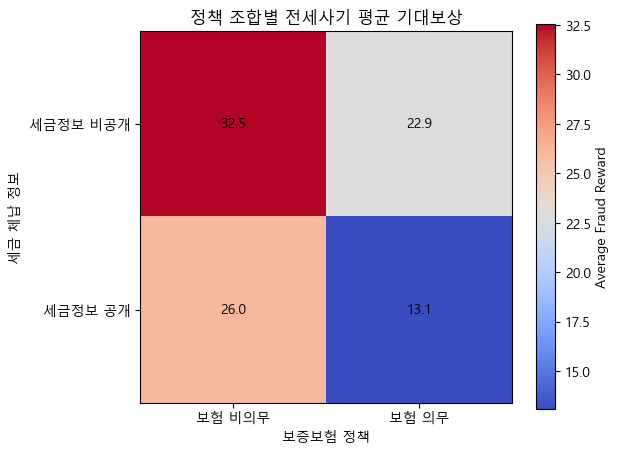

In [42]:
import matplotlib.font_manager as fm
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_prop = fm.FontProperties(fname=font_path, size=12)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(6, 5))
plt.imshow(heatmap, cmap="coolwarm")
plt.colorbar(label="Average Fraud Reward")

plt.xticks([0, 1], ["보험 비의무", "보험 의무"])
plt.yticks([0, 1], ["세금정보 비공개", "세금정보 공개"])

plt.title("정책 조합별 전세사기 평균 기대보상")
plt.xlabel("보증보험 정책")
plt.ylabel("세금 체납 정보")

for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{heatmap[i,j]:.1f}",
                 ha="center", va="center", color="black")

plt.show()
